# Astrometry models

Looking into the astrometric models provided by David and seeing how best to use them


## Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from gaianir_open_clusters.gaia_nir_config import ASTROMETRIC_DATA
from gaianir_open_clusters.astrometry import (
    AstrometryModel,
    AstrometryModelElectronBased,
    _effective_temperature_map
)
from gaianir_open_clusters.photometry import PHOTOMETRY_PREDICTOR, FILTERS
from ocelot.simulate.photometry import load_isochrone
from astropy import constants
from scipy.interpolate import interp1d

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


## Reproducing plots in the Hobbs+ paper


In [64]:
gaia_dr5 = AstrometryModel(years=10, mission="Gaia")
gaia_nir_l = AstrometryModel(years=10, mission="GaiaNIR-L")
gaia_nir_electron = AstrometryModelElectronBased(years=10, mission="GaiaNIR-L")

In [3]:
def combined_astrometry(stars, model_1, model_2, separation=20, max_magnitude=None):
    pmra_error_1, pmdec_error_1, _ = model_1.predict(stars)
    pmra_error_2, pmdec_error_2, parallax_error = model_2.predict(stars)

    separation = model_1.years / 2 + model_2.years / 2 + separation

    pmra_error_combined = (pmra_error_1**-2 + pmra_error_2**-2) ** -0.5 / separation
    pmdec_error_combined = (pmdec_error_1**-2 + pmdec_error_2**-2) ** -0.5 / separation

    if max_magnitude is not None:
        do_not_combine = stars['G'] > max_magnitude
        pmra_error_combined[do_not_combine] = pmra_error_2[do_not_combine]
        pmdec_error_combined[do_not_combine] = pmdec_error_2[do_not_combine]

    return (
        pmra_error_2,
        pmdec_error_2,
        parallax_error,
        pmra_error_combined,
        pmdec_error_combined,
    )

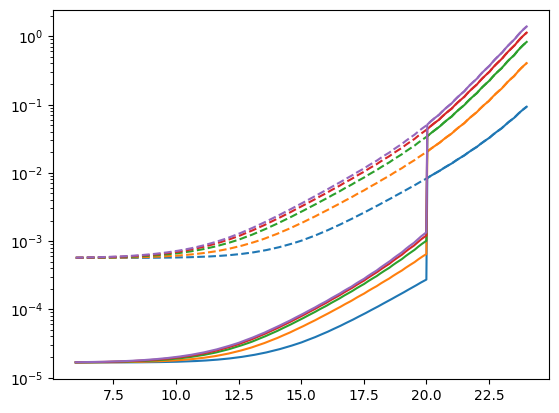

In [27]:
fig, ax = plt.subplots()

cmap = plt.get_cmap("tab10")

for i, teff in enumerate(np.geomspace(3500, 15000, num=5)):
    stars = pd.DataFrame.from_dict(
        dict(teff=teff, label=0, G=np.linspace(6, 24, num=500))
    )
    (
        pmra_error,
        pmdec_error,
        parallax_error,
        pmra_error_combined,
        pmdec_error_combined,
    ) = combined_astrometry(stars, gaia_dr5, gaia_nir_l, max_magnitude=20)
    # pmra_error, pmdec_error, parallax_error = gaia_nir_l.predict(stars)

    color = cmap(i)
    ax.plot(stars["G"], pmra_error, "--", color=color)
    ax.plot(stars["G"], pmra_error_combined, color=color)
    # ax.plot(
    #     stars["G"],
    #     gaia_nir_electron.predict(stars["G"] + n_int(stars["teff"]))[0],
    #     ":",
    #     color=color,
    # )
    ax.set(yscale="log")

## With an electron-based model

In [2]:
class Params:
    log_age = np.log10(3e8)
    metallicity = 0.0


class Dummy:
    parameters = Params()


iso = load_isochrone(Dummy())
iso["temperature"] = 10 ** iso["logTe"]
iso["luminosity"] = 10 ** iso["logL"] * constants.L_sun.value

# _ = gaia_nir_phot.predict(iso)

predictions = PHOTOMETRY_PREDICTOR.predict(iso)

iso_good = iso.loc[iso["label"] < 2]

# g_int = interp1d(iso_good['temperature'], iso_good['Gmag'])
n_int = interp1d(
    iso_good["temperature"], iso_good["N"] - iso_good["Gmag"], bounds_error=False
)


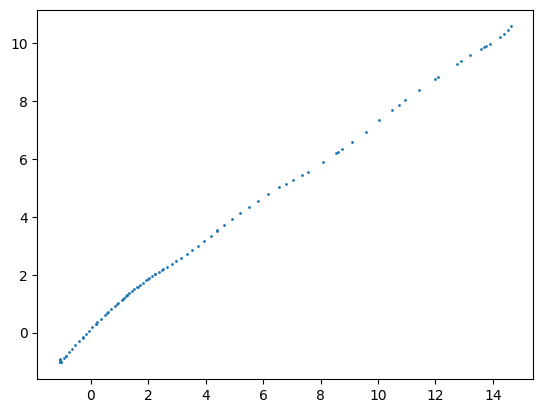

In [3]:
plt.scatter(iso_good['Gmag'], iso_good['N'], s=1)

In [4]:
years = 5
mission = "GaiaNIR-L"

model_normal = AstrometryModel(years=years, mission=mission)
model_electron = AstrometryModelElectronBased(years=years, mission=mission)

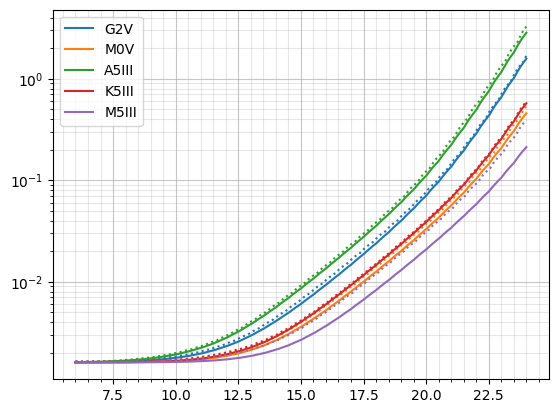

In [5]:
fig, ax = plt.subplots()

cmap = plt.get_cmap("tab10")

i = 0
for star_type, teff in _effective_temperature_map.items():
    if teff > 10000 or teff < 3000:
        continue
    stars = pd.DataFrame.from_dict(
        dict(teff=teff, label=0, G=np.linspace(6, 24, num=500))
    )
    pmra_error, pmdec_error, parallax_error = model_normal.predict(stars)

    color = cmap(i)
    ax.plot(stars["G"], pmra_error, "-", color=color, label=star_type)
    ax.plot(
        stars["G"],
        model_electron.predict(stars["G"] + n_int(stars["teff"]))[0],
        ":",
        color=color,
    )
    i += 1
    
ax.set(yscale="log")
ax.grid(which="major", alpha=0.7)
ax.minorticks_on()
ax.grid(which="minor", alpha=0.3)
ax.legend()

Yay! Those residuals are tiny =)

The only big difference is for an M5 star, but that may also be a PARSEC photometric issue that I won't easily be able to beat.

## Thinking about fair extension methods

In [17]:
class Params:
    log_age = np.log10(1e9)
    metallicity = 0.0


class Dummy:
    parameters = Params()


iso = load_isochrone(Dummy())
iso["temperature"] = 10 ** iso["logTe"]
iso["luminosity"] = 10 ** iso["logL"] * constants.L_sun.value

# _ = gaia_nir_phot.predict(iso)

predictions = PHOTOMETRY_PREDICTOR.predict(iso)


In [18]:
iso_good = iso.loc[iso['label'] < 2]

g_int = interp1d(iso_good['temperature'], iso_good['Gmag'])
n_int = interp1d(iso_good['temperature'], iso_good['N'])

g_to_n_int = interp1d(iso_good['Gmag'], iso_good['N'])

In [70]:
temp = 3980
distance = 25.83189

d_factor = 5 * np.log10(distance) - 5
print(g_int(temp) + d_factor)
print(n_int(temp) + d_factor)

10.000000507314052
7.852563729071847


In [77]:
def mag_to_electrons(mag):
    # Magic number that calibrates from David's GaiaNIR sims (which include e.g. the 
    # telescope size) against mine
    # calibration_factor = 427.54392151861185 / 10.738344786983658
    calibration_factor = 1

    return 10 ** ((mag - FILTERS["N"].Vega_zero_mag) / -2.5) * calibration_factor

In [81]:
427.54392151861185 / 10.738344786983658

39.814694908739895

In [79]:
169577076.79493374 / mag_to_electrons(n_int(temp) + d_factor)

np.float64(45.766973309443344)

In [153]:
temp = 25600
distance = 623.6

d_factor = 5 * np.log10(distance) - 5
print(g_int(temp) + d_factor)
# print()

6.000264930911065


In [156]:
mag_to_electrons(n_int(temp) + d_factor)

np.float64(474372467.396921)

In [28]:
predictions = PHOTOMETRY_PREDICTOR.predict(iso)

predictions[['temperature', 'Gmag', 'N']]

,temperature,Gmag,N
0,2307.809730,15.376,11.347790
1,2450.755579,14.916,10.875481
2,2618.183008,14.349,10.335450
3,2657.663550,14.147,10.219619
4,2782.274658,13.422,9.776406
...,...,...,...
365,4474.041416,-0.320,-2.058232
366,4446.312675,-0.391,-2.150319
367,4421.809211,-0.454,-2.231430
368,4397.440784,-0.514,-2.312622
